# LSTM Model Version 1 Testing

## Goal & Setup

- **Task:** given the past week of weather, predict the next 24 hours
- **Target:** start with a **single variable** (e.g. `temperature`) — predicting multiple targets is a later extension (noted in Phase 3)
- **Data:** 4-year subset of hourly weather (~35,000 rows) to keep experiments fast
- **Approach:** direct multi-step forecast — the model outputs all 24 future values at once via a `Dense(24)` head


In [25]:
# Data Import
import sys
sys.path.append('../notebooks/Jacques')
from full_cleaning_preprocessing_script import run_full_preprocessing

# General
import pandas as pd
import numpy as np
import os
from typing import List
import matplotlib.pyplot as plt

# Metrics Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep Learning Architecture
from keras import models, Input, layers, optimizers, regularizers
from keras.layers import Normalization
from keras.optimizers.schedules import ExponentialDecay
from keras.callbacks import EarlyStopping

## Phase 0 — Inputs (what the model expects)

In [5]:
df = run_full_preprocessing(
    data_folder = "/home/jpelletier/Downloads/data",
    start_date = "2019-01-01",
    end_date = "2024-12-31",
    save_path = "/home/jpelletier/Downloads/data/preprocessed_data.csv"
)

DUCKSTRADAMUS — FULL PREPROCESSING PIPELINE
  data_folder : /home/jpelletier/Downloads/data
  date range  : 2019-01-01  →  2024-12-31
  save_path   : /home/jpelletier/Downloads/data/preprocessed_data.csv

[1/9] Wholesale price...
      Anchor df shape: (52585, 10)

[2/9] Generation output...
      Shape after merge: (52585, 19)

[3/9] Wind...
      Shape after merge: (52585, 29)

[4/9] Solar...
      Shape after merge: (52585, 41)

[5/9] Temperature...
      Shape after merge: (52585, 47)

[6/9] Lake storage...
      Merged: NI_TPO_Storage_LakeTaupo.csv  (prefix: 'NI_TPO_')
      Merged: NI_WKA_Storage_LakeWaikaremoana.csv  (prefix: 'NI_WKA_')
      Merged: SI_HWE_Storage_LakeHawea.csv  (prefix: 'SI_HWE_')
      Merged: SI_MAN_Storage_LakeManapouri.csv  (prefix: 'SI_MAN_')
      Merged: SI_OHA_Storage_LakeOhau.csv  (prefix: 'SI_OHA_')
      Merged: SI_PKI_Storage_LakePukaki.csv  (prefix: 'SI_PKI_')
      Merged: SI_TAU_Storage_LakeTeAnau.csv  (prefix: 'SI_TAU_')
      Merged: SI_TKA_St

In [6]:
df = df.set_index('datetime_utc12').sort_index()

In [7]:
print(df.shape)
print(df.columns.tolist())
df.head()

(52585, 80)
['el_price_dol_MWh_BEN2201', 'el_price_dol_MWh_HAY2201', 'el_price_dol_MWh_INV2201', 'el_price_dol_MWh_ISL2201', 'el_price_dol_MWh_KIK2201', 'el_price_dol_MWh_OTA2201', 'el_price_dol_MWh_RDF2201', 'el_price_dol_MWh_SFD2201', 'el_price_dol_MWh_WKM2201', 'Coal', 'Diesel', 'Ele', 'Gas', 'Geo', 'Hydro', 'Solar', 'Wind', 'Wood', 'palmerston_north_wind_kmh', 'palmerston_north_wind_dir_deg', 'wellington_wind_kmh', 'wellington_wind_dir_deg', 'harapaki_hawkesbay_wind_kmh', 'harapaki_hawkesbay_wind_dir_deg', 'te_uku_waikato_wind_kmh', 'te_uku_waikato_wind_dir_deg', 'kaiwera_downs_southland_wind_kmh', 'kaiwera_downs_southland_wind_dir_deg', 'auckland_shortwave_wm2', 'auckland_sunshine_s', 'christchurch_shortwave_wm2', 'christchurch_sunshine_s', 'wellington_shortwave_wm2', 'wellington_sunshine_s', 'hamilton_shortwave_wm2', 'hamilton_sunshine_s', 'tauranga_shortwave_wm2', 'tauranga_sunshine_s', 'dunedin_shortwave_wm2', 'dunedin_sunshine_s', 'auckland_temp_c', 'christchurch_temp_c', 'wel

,el_price_dol_MWh_BEN2201,el_price_dol_MWh_HAY2201,el_price_dol_MWh_INV2201,el_price_dol_MWh_ISL2201,el_price_dol_MWh_KIK2201,el_price_dol_MWh_OTA2201,el_price_dol_MWh_RDF2201,el_price_dol_MWh_SFD2201,el_price_dol_MWh_WKM2201,Coal,...,demand_GWh_UNI,demand_GWh_USI,avg_flow_MW,peak_flow_MW,Direction,outage_Gas_MW,outage_Hyd_MW,outage_Ter_MW,outage_Win_MW,outage_UNKN_MW
datetime_utc12,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,169.985,171.76,180.715,181.835,184.255,176.515,166.425,169.515,167.185,0.0,...,0.910,0.528,137.5,148.0,1.0,40.0,84.0,590.0,48.3,14.0
2019-01-01 01:00:00,156.335,157.87,166.360,167.215,169.400,162.070,152.940,155.645,153.635,0.0,...,0.889,0.483,129.5,133.0,1.0,40.0,84.0,590.0,48.3,14.0
2019-01-01 02:00:00,139.650,141.00,148.550,149.095,151.050,144.645,136.500,138.990,137.120,0.0,...,0.853,0.457,126.0,128.0,1.0,40.0,84.0,590.0,48.3,14.0
2019-01-01 03:00:00,128.845,129.98,137.375,137.215,139.015,133.355,125.830,128.130,126.400,0.0,...,0.833,0.446,126.5,132.0,1.0,40.0,84.0,590.0,48.3,14.0
2019-01-01 04:00:00,134.865,136.14,144.585,143.745,145.670,139.955,132.130,134.465,132.725,0.0,...,0.835,0.460,146.0,155.0,1.0,40.0,84.0,590.0,48.3,14.0


## Create Naive Baseline

In [8]:
df['naive_baseline'] = df['el_price_dol_MWh_OTA2201'].shift(1)


In [9]:
# Drop the first row since shift(1) gives NaN there
mask = df['naive_baseline'].notna()

mae  = mean_absolute_error(df.loc[mask, 'el_price_dol_MWh_OTA2201'], df.loc[mask, 'naive_baseline'])
rmse = np.sqrt(mean_squared_error(df.loc[mask, 'el_price_dol_MWh_OTA2201'], df.loc[mask, 'naive_baseline']))

print(f'MAE  : {mae:.4f}')
print(f'RMSE : {rmse:.4f}')

MAE  : 23.6814
RMSE : 72.6089


## Phase 1 — Lastmile Preprocessing

### Observations

Some columns with 18 and 6 missing values. Will simply impute and fill given extremely low percentage of these values (0.03% and 0.01%, respectivelly.

Check with:
- df.isnull().sum()
- df.isnull().sum() / len(df) * 100

In [10]:
pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.reset_option('display.max_rows')

In [11]:
# 1. Ensure chronological order, no gaps
df = df.sort_index()

In [12]:
# 2. Handle missing values (weather sensors have gaps)
#    Forward-fill carries the last reading; back-fill covers any leading NaNs
df = df.ffill().bfill()

In [13]:
# 3. Add cyclical time features — helps the model learn daily & yearly rhythm
#    (Same sin/cos trick as the generation-data cyclic encoding)
hour = df.index.hour
doy  = df.index.dayofyear
df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * hour / 24)
df['doy_sin']  = np.sin(2 * np.pi * doy / 365)
df['doy_cos']  = np.cos(2 * np.pi * doy / 365)

In [14]:
# 4. (Optional) keep only the features you want the model to see
#    Fewer, relevant features = faster training and less overfitting on a small dataset

> **⚠️ Leakage note (different from David's Prophet case):**
> David had to lag his price/production features by 24h because they would otherwise leak the future. For a *pure weather → weather* LSTM, the sliding-window construction in Phase 2 handles this structurally: `X` only ever contains the **past** window, and `y` only the **future** window. So no manual lagging is needed — **as long as every feature you include is something genuinely available at prediction time.** If you later add a feature that "knows the future," you'd need to lag it like David did.

## Phase 2 — Data Preparation (Time Series sequences)

In [15]:
# ─── Configuration (all TUNE-able) ──────────────────────────────────
TARGET           = 'el_price_dol_MWh_OTA2201'   # TUNE: the weather variable to predict
INPUT_LENGTH     = 168             # TUNE: 7 days of hourly history as input. CHANGE LATER TO 336 TO LOOK AT 2 WEEKS
OUTPUT_LENGTH    = 24              # fixed: predict 24 hours ahead. CHANGE LATER TO 168 TO PREDICT 1 WEEK
HORIZON          = 1               # gap between last input and first prediction
STRIDE           = 1               # TUNE: step between consecutive sequences
FOLD_LENGTH      = 24 * 365        # TUNE: 1 year per fold
FOLD_STRIDE      = 24 * 182        # TUNE: ~6 month stride between folds
TRAIN_TEST_RATIO = 0.8

# Index of the target column WITHIN the feature array (needed for the baseline)
TARGET_COLUMN_IDX = df.columns.get_loc(TARGET)

In [16]:
# ─── Step 1: Create folds (sliding window over full dataset) ─────────
def get_folds(df: pd.DataFrame, fold_length: int, fold_stride: int) -> List[pd.DataFrame]:
    folds = []
    for idx in range(0, len(df), fold_stride):
        if (idx + fold_length) > len(df):
            break
        folds.append(df.iloc[idx:idx + fold_length, :])
    return folds

In [17]:
# ─── Step 2: Chronological train/test split per fold (with horizon gap) ──
def train_test_split(fold, train_test_ratio, input_length, horizon):
    train_end  = round(train_test_ratio * len(fold))
    test_start = train_end - input_length + horizon   # leaves lookback + gap
    return fold.iloc[:train_end], fold.iloc[test_start:]

In [18]:
# ─── Step 3: Extract (Xi, yi) sequence pairs ─────────────────────────
# NOTE: simplified from the bootcamp version to use positional indexing,
# so it works with a DatetimeIndex (the bootcamp version assumed a RangeIndex).
def get_X_y(fold, horizon, input_length, output_length, stride, shuffle=True):
    X, y = [], []
    n = len(fold)
    last_start = n - input_length - horizon - output_length + 2
    for start in range(0, last_start, stride):
        Xi = fold.iloc[start : start + input_length]
        y_start = start + input_length + horizon - 1
        yi = fold.iloc[y_start : y_start + output_length][TARGET]
        X.append(Xi.values)
        y.append(yi.values)
    X, y = np.array(X), np.array(y)
    if shuffle:
        idx = np.random.permutation(len(X))
        X, y = X[idx], y[idx]
    return X, y

In [19]:
# ─── Build folds and a first (Xi, yi) set to sanity-check shapes ─────
folds = get_folds(df, FOLD_LENGTH, FOLD_STRIDE)

fold_train, fold_test = train_test_split(folds[0], TRAIN_TEST_RATIO, INPUT_LENGTH, HORIZON)
X_train, y_train = get_X_y(fold_train, HORIZON, INPUT_LENGTH, OUTPUT_LENGTH, STRIDE)
X_test,  y_test  = get_X_y(fold_test,  HORIZON, INPUT_LENGTH, OUTPUT_LENGTH, STRIDE, shuffle=False)

print(f"Number of folds: {len(folds)}")
print(f"X_train: {X_train.shape}")   # (n_sequences, INPUT_LENGTH, N_FEATURES)
print(f"y_train: {y_train.shape}")   # (n_sequences, OUTPUT_LENGTH)

Number of folds: 11
X_train: (6817, 168, 85)
y_train: (6817, 24)


## Phase 3 — Architecture

In [ ]:
def init_model(X_train):
    # Normalization baked into the model, fitted on TRAIN data only (no leakage)
    normalizer = Normalization()
    normalizer.adapt(X_train)

    model = models.Sequential()
    model.add(Input(shape=X_train[0].shape))     # (INPUT_LENGTH, N_FEATURES)
    model.add(normalizer)

    # Recurrent layer
    model.add(layers.LSTM(units=64,               # MAKE EDITS HERE IF NEEDED: 32 OR 64
                          activation='tanh',      # alternative "SWISH or Swiss"
                          return_sequences=False,
                          dropout=0.2))           # TUNE: lighter than bootcamp 0.5

    # Dense hidden layer
    model.add(layers.Dense(32, activation='relu'))  # TUNE
    model.add(layers.Dropout(0.2))                  # TUNE

    # Output — one neuron per future timestep (24)
    model.add(layers.Dense(OUTPUT_LENGTH, activation='linear'))

    # Exponential decay learning rate
    lr_schedule = ExponentialDecay(initial_learning_rate=0.01,   # TUNE
                                   decay_steps=1000,
                                   decay_rate=0.5)
    model.compile(loss='mse',                                   # MAKE EDITS: change to MAE or Huber
                  optimizer=optimizers.Adam(learning_rate=lr_schedule),
                  metrics=['mae', 'root_mean_squared_error'])              # MAKE EDITS: change metrics reported if needed
    return model

In [28]:
model = init_model(X_train)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 168, 85)        │           171 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        38,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,443 (161.89 KB)

 Trainable params: 41,272 (161.22 KB)

 Non-trainable params: 171 (688.00 B)

## Phase 4 — Fit

In [31]:
def fit_model(model, X_train, y_train, verbose=1):
    es = EarlyStopping(monitor='val_loss',
                       patience=3,            # TUNE
                       mode='min',
                       restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_split = 0.3,
        shuffle          = False,   # MANDATORY for time series
        batch_size       = 32,      # TUNE
        epochs           = 50,     # early stopping decides the real number
        callbacks        = [es],
        verbose          = verbose,
    )
    return model, history

In [32]:
model, history = fit_model(model, X_train, y_train)

Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - loss: 2438.5144 - mae: 32.3868 - root_mean_squared_error: 49.3813 - val_loss: 2070.8235 - val_mae: 29.2878 - val_root_mean_squared_error: 45.5063
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - loss: 2376.1831 - mae: 31.9335 - root_mean_squared_error: 48.7461 - val_loss: 2052.8062 - val_mae: 29.3576 - val_root_mean_squared_error: 45.3079
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - loss: 2375.6970 - mae: 31.9395 - root_mean_squared_error: 48.7411 - val_loss: 2036.1753 - val_mae: 29.2027 - val_root_mean_squared_error: 45.1240
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - loss: 2368.8303 - mae: 31.8847 - root_mean_squared_error: 48.6706 - val_loss: 2025.7900 - val_mae: 29.3379 - val_root_mean_squared_error: 45.0088
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - loss: 2342.7239 - mae: 31.8884 - root_mean_squared_error: 48.4017 - val_loss: 1988.2009 - val_mae: 28.7490 - val_root_mean_squared_error:

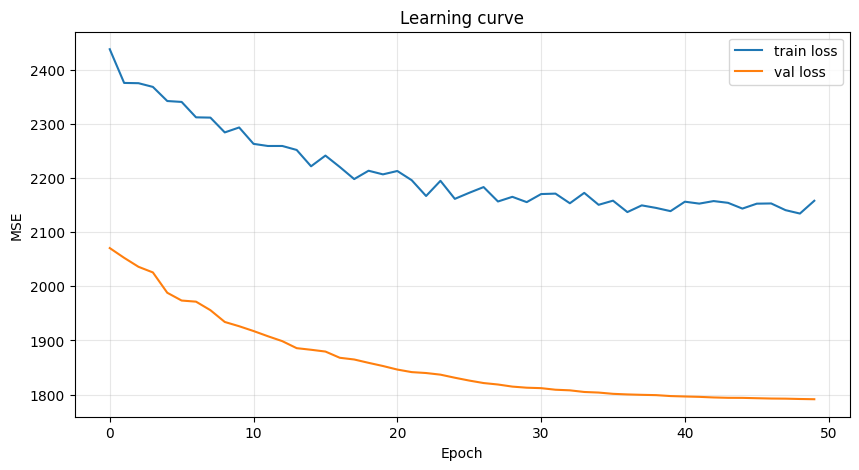

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'],     label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend()
plt.title('Learning curve'); plt.grid(alpha=0.3)
plt.show()

## Phase 5 — Evaluate & Cross-Validate

### Single-fold evaluation + baseline

In [34]:
# LSTM performance on this fold's test set
res = model.evaluate(X_test, y_test, verbose=0)
mae_lstm = res[1]

# Baseline: repeat the last seen target value across all 24 future hours
def last_seen_value_baseline(X_test, y_test):
    last_seen = X_test[:, -1, TARGET_COLUMN_IDX].reshape(-1, 1)
    repeated  = np.repeat(last_seen, axis=1, repeats=OUTPUT_LENGTH)
    return np.mean(np.abs(y_test - repeated))

mae_baseline = last_seen_value_baseline(X_test, y_test)

print(f"Baseline MAE: {mae_baseline:.3f}")
print(f"LSTM MAE:     {mae_lstm:.3f}")
print(f"Improvement:  {(1 - mae_lstm/mae_baseline)*100:.1f}%")

Baseline MAE: 37.865
LSTM MAE:     48.563
Improvement:  -28.3%


## Phase 6 — Predict the Next 24 Hours

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
2024-12-31 01:00:00    102.764015
2024-12-31 02:00:00     99.588715
2024-12-31 03:00:00     95.408745
2024-12-31 04:00:00     91.644249
2024-12-31 05:00:00     87.270020
2024-12-31 06:00:00     83.172424
2024-12-31 07:00:00     79.141640
2024-12-31 08:00:00     75.390671
2024-12-31 09:00:00     72.866486
2024-12-31 10:00:00     71.123802
2024-12-31 11:00:00     70.532410
2024-12-31 12:00:00     70.818069
2024-12-31 13:00:00     71.875282
2024-12-31 14:00:00     73.837730
2024-12-31 15:00:00     76.816238
2024-12-31 16:00:00     79.744896
2024-12-31 17:00:00     82.879753
2024-12-31 18:00:00     87.113068
2024-12-31 19:00:00     90.732613
2024-12-31 20:00:00     93.751350
2024-12-31 21:00:00     97.159950
2024-12-31 22:00:00     99.756027
2024-12-31 23:00:00    101.650452
2025-01-01 00:00:00    100.972672
Freq: h, Name: el_price_dol_MWh_OTA2201_forecast, dtype: float32


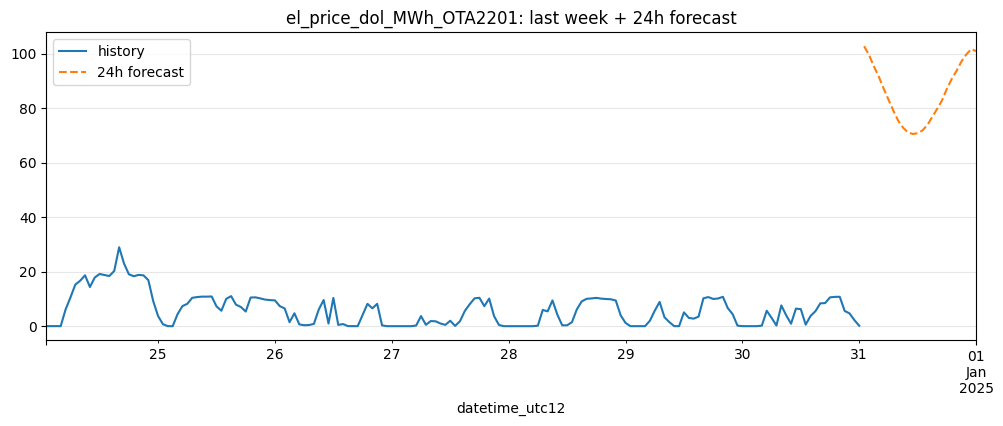

In [ ]:
# Build a single input window from the most recent data
latest_window = df.iloc[-INPUT_LENGTH:].values            # (INPUT_LENGTH, N_FEATURES)
latest_window = latest_window[np.newaxis, ...]            # (1, INPUT_LENGTH, N_FEATURES)

# Predict the next 24 hours
forecast_24h = model.predict(latest_window)[0]            # shape (24,)

# Attach future timestamps for readability
last_ts = df.index[-1]
future_index = pd.date_range(last_ts + pd.Timedelta(hours=1), periods=OUTPUT_LENGTH, freq='h')
forecast_series = pd.Series(forecast_24h, index=future_index, name=f'{TARGET}_forecast')

print(forecast_series)

# Quick visual
plt.figure(figsize=(12, 4))
df[TARGET].iloc[-INPUT_LENGTH:].plot(label='history')
forecast_series.plot(label='24h forecast', linestyle='--')
plt.legend(); plt.title(f'{TARGET}: last week + 24h forecast'); plt.grid(alpha=0.3)
plt.show()